###**Dependencies**

In [ ]:
# Install Ultralytics (for YOLOv8)
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9

###**Custom Training PyTorch YOLOv8 Model**

#### Retrieving Training Dataset

In [ ]:
# Import necessary libraries
from roboflow import Roboflow

rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("WORKSPACE_ID").project("PROJECT_ID")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Branding-3 in yolov8:: 100%|██████████| 120/120 [00:00<00:00, 6209.72it/s]


#### Training Model

In [ ]:
# Check if YOLOv8 is installed properly
from ultralytics import YOLO

# Train YOLOv8 Model
!yolo task=detect mode=train model=yolov8s.pt data=/content/Branding-3/data.yaml epochs=100 imgsz=640 batch=16 device=0

Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/Branding-3/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_box

###**Retrieving Custom Trained Model and Test Dataset**

#### Retrieving Test Dataset

In [ ]:
import os
import zipfile
import gdown
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Google Drive file IDs
IMAGE_ZIP_ID = "1zqQfTSeCL1Cu2Aj6yeVEaVOHlcBiS2ZX"
MODEL_FILE_ID = "1xpJeOlUn2R65nnn_DfYYK8zOvxB0L5d-"

# Define file paths
IMAGE_ZIP_PATH = "./images.zip"
MODEL_PATH = "./yolov8_model.pt"
IMAGE_DIR = "./"

# Download images zip
gdown.download(f"https://drive.google.com/uc?id={IMAGE_ZIP_ID}", IMAGE_ZIP_PATH, quiet=False)

# Download YOLOv8 model
gdown.download(f"https://drive.google.com/uc?id={MODEL_FILE_ID}", MODEL_PATH, quiet=False)

# Extract images
os.makedirs(IMAGE_DIR, exist_ok=True)
with zipfile.ZipFile(IMAGE_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(IMAGE_DIR)

# Load YOLOv8 model
model = YOLO(MODEL_PATH)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Downloading...
From: https://drive.google.com/uc?id=1zqQfTSeCL1Cu2Aj6yeVEaVOHlcBiS2ZX
To: /content/images.zip
100%|██████████| 628k/628k [00:00<00:00, 113MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xpJeOlUn2R65nnn_DfYYK8zOvxB0L5d-
To: /content/yolov8_model.pt
100%|██████████| 22.5M/22.5M [00:01<00:00, 18.0MB/s]


#### Testing Model


image 1/1 /content/test/Page8.png: 480x640 1 bad_donut_chart, 1 bad_logo, 1 bad_success_tag, 1 good_donut_chart, 2 good_error_tags, 1 good_success_tag, 14.0ms
Speed: 2.6ms preprocess, 14.0ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


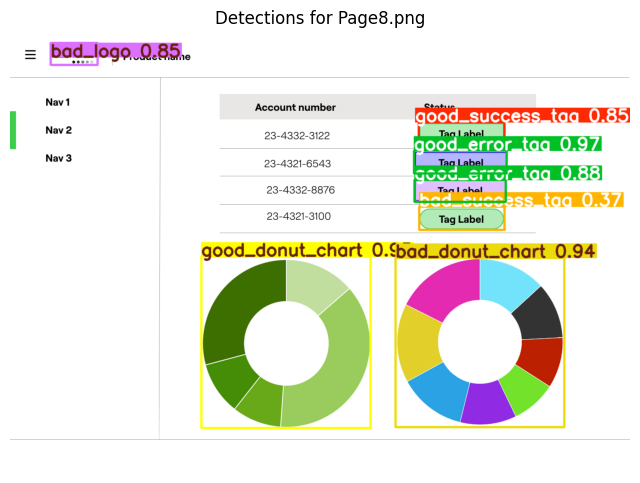


image 1/1 /content/test/Page12-3.png: 480x640 1 bad_disabled_button, 1 bad_general_tag, 1 bad_large_card, 1 bad_logo, 1 bad_small_card, 1 good_general_tag, 1 good_large_card, 1 good_logo, 2 good_small_cards, 1 good_static_button, 13.3ms
Speed: 2.6ms preprocess, 13.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


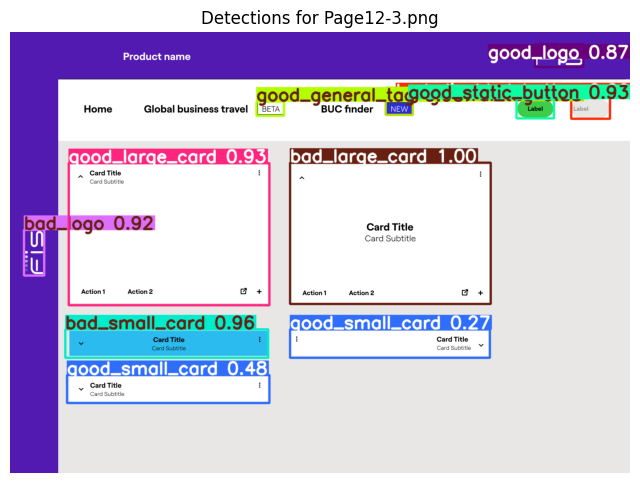


image 1/1 /content/test/Page21.png: 480x640 1 bad_logo, 3 bad_static_buttons, 1 good_disabled_button, 1 good_logo, 1 good_pie_chart, 1 good_static_button, 13.2ms
Speed: 2.7ms preprocess, 13.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


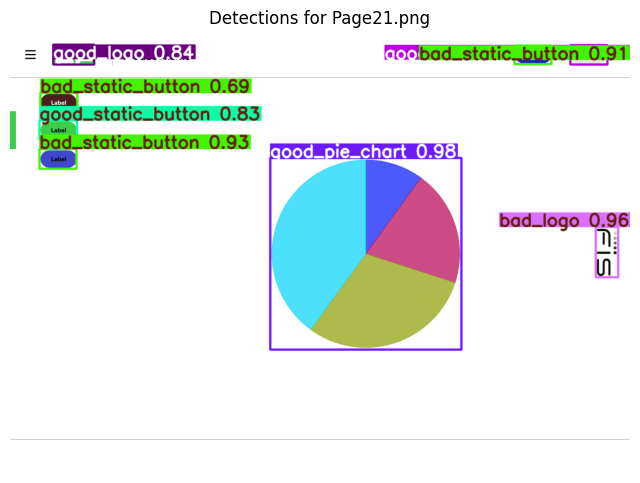


image 1/1 /content/test/Page12-1.png: 480x640 1 bad_error_tag, 2 bad_general_tags, 1 bad_logo, 1 bad_status_tag, 3 bad_success_tags, 1 good_error_tag, 2 good_logos, 1 good_pie_chart, 1 good_success_tag, 13.3ms
Speed: 2.6ms preprocess, 13.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


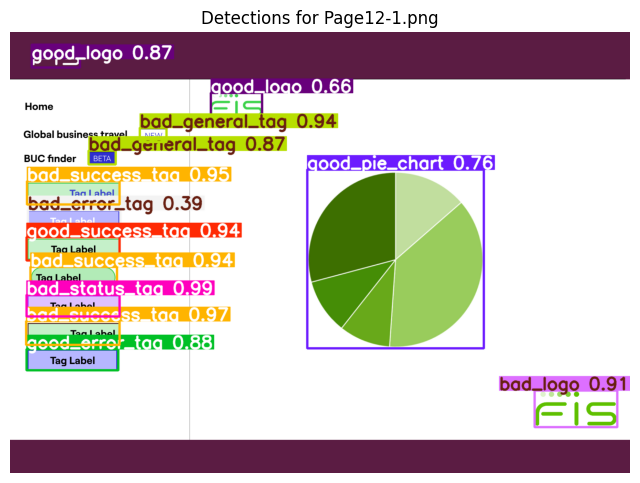


image 1/1 /content/test/Page18-1.png: 480x640 2 bad_large_cards, 1 bad_small_card, 1 bad_status_tag, 3 bad_success_tags, 1 good_disabled_button, 1 good_error_tag, 1 good_logo, 3 good_small_cards, 2 good_static_buttons, 1 good_success_tag, 13.3ms
Speed: 2.7ms preprocess, 13.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


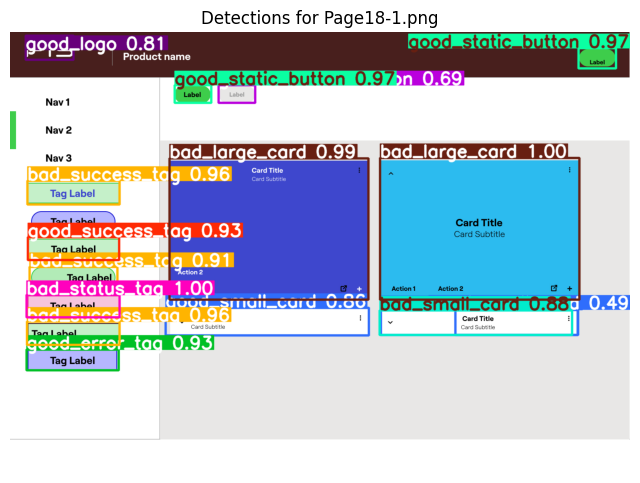


image 1/1 /content/test/Page18.png: 480x640 2 bad_large_cards, 1 bad_small_card, 1 bad_status_tag, 3 bad_success_tags, 1 good_disabled_button, 1 good_error_tag, 1 good_logo, 3 good_small_cards, 2 good_static_buttons, 1 good_success_tag, 15.2ms
Speed: 4.5ms preprocess, 15.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


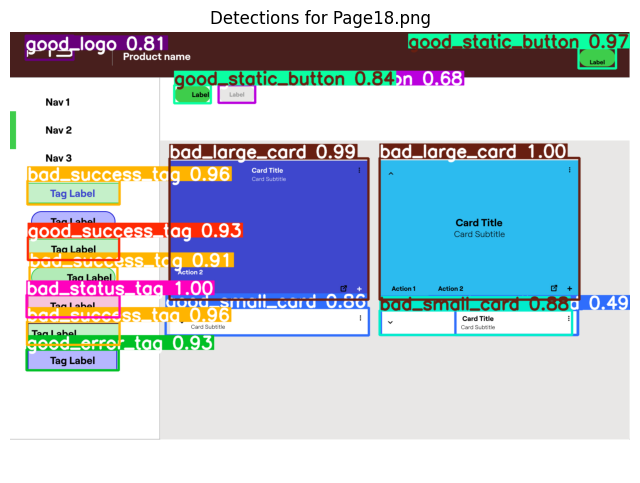


image 1/1 /content/test/Page13.png: 480x640 1 bad_general_tag, 1 bad_large_card, 2 bad_static_buttons, 1 good_disabled_button, 1 good_general_tag, 2 good_large_cards, 1 good_logo, 1 good_small_card, 13.3ms
Speed: 4.7ms preprocess, 13.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


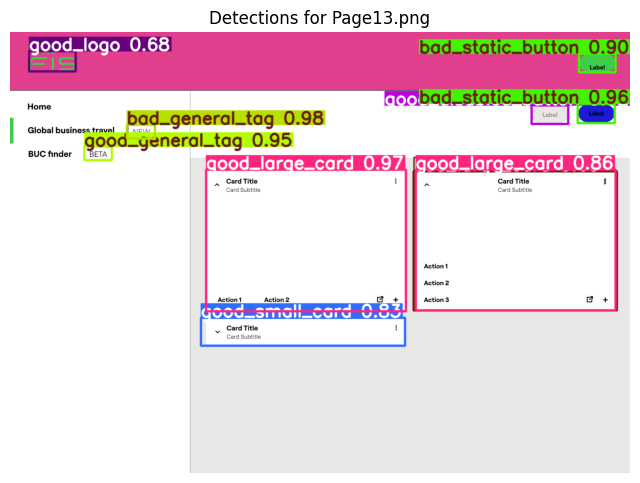


image 1/1 /content/test/Page12-2.png: 480x640 1 bad_general_tag, 1 bad_pie_chart, 1 good_disabled_button, 1 good_donut_chart, 1 good_general_tag, 1 good_logo, 2 good_static_buttons, 13.3ms
Speed: 6.8ms preprocess, 13.3ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)


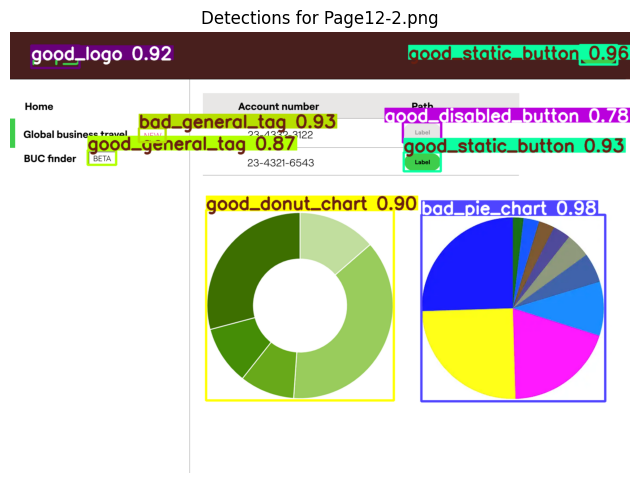


image 1/1 /content/test/Page12.png: 480x640 1 bad_disabled_button, 1 bad_large_card, 1 bad_logo, 1 bad_pie_chart, 1 bad_static_button, 2 good_general_tags, 1 good_large_card, 1 good_pie_chart, 2 good_static_buttons, 13.3ms
Speed: 4.3ms preprocess, 13.3ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


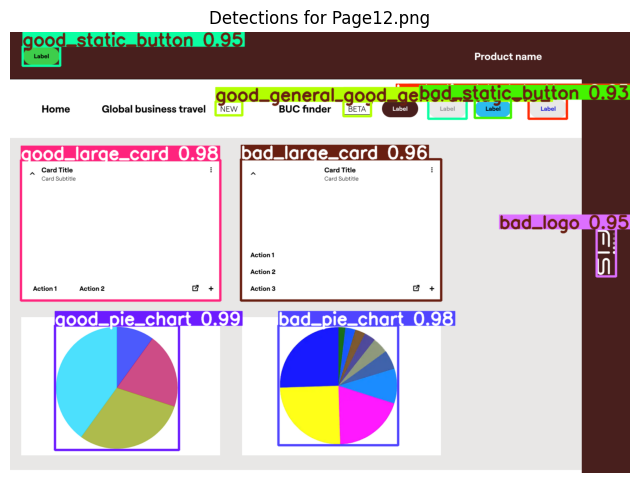


image 1/1 /content/test/Page19.png: 480x640 1 bad_general_tag, 1 bad_logo, 1 bad_static_button, 1 good_general_tag, 2 good_large_cards, 1 good_pie_chart, 2 good_static_buttons, 13.3ms
Speed: 4.7ms preprocess, 13.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


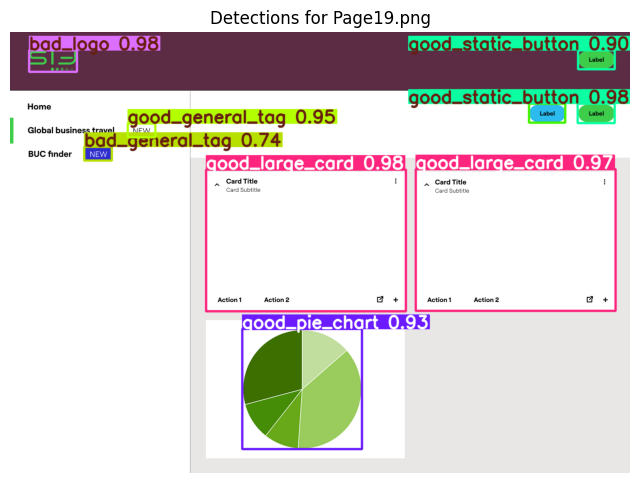

In [ ]:
# Run inference on all images in the directory
IMAGE_DIR = "./test/"
image_files = [os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]

for image_file in image_files:
    results = model(image_file)

    # Display results
    for result in results:
        img = cv2.imread(image_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8, 6))
        plt.imshow(result.plot())  # YOLO automatically plots detections
        plt.axis("off")
        plt.title(f"Detections for {os.path.basename(image_file)}")
        plt.show()

###**Detecting Clear Space Around Logo Using OpenCV and Model**

Download complete.

image 1/1 /content/test/Page8.png: 480x640 1 bad_donut_chart, 1 bad_logo, 1 bad_success_tag, 1 good_donut_chart, 2 good_error_tags, 1 good_success_tag, 179.7ms
Speed: 17.5ms preprocess, 179.7ms inference, 483.1ms postprocess per image at shape (1, 3, 480, 640)


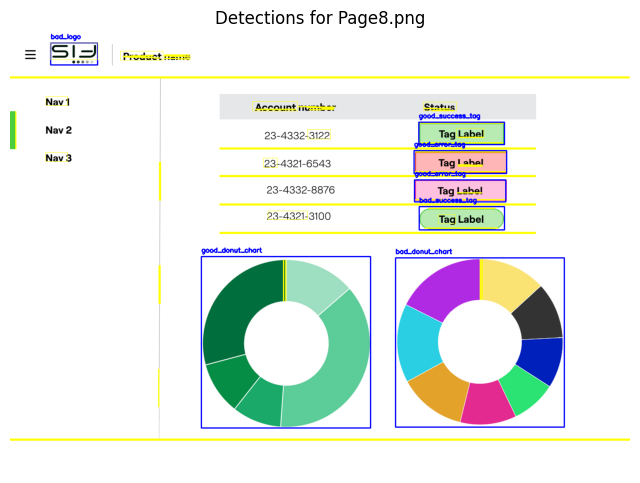


image 1/1 /content/test/Page12-3.png: 480x640 1 bad_disabled_button, 1 bad_general_tag, 1 bad_large_card, 1 bad_logo, 1 bad_small_card, 1 good_general_tag, 1 good_large_card, 1 good_logo, 2 good_small_cards, 1 good_static_button, 13.2ms
Speed: 2.7ms preprocess, 13.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Bounding Box size: 112	Minimum clearance: 32.0
Bounding Box (1219, 28, 1331, 81) - Distances: {'Up': 28, 'Down': np.int32(24), 'Left': 863, 'Right': 109} - INVALID


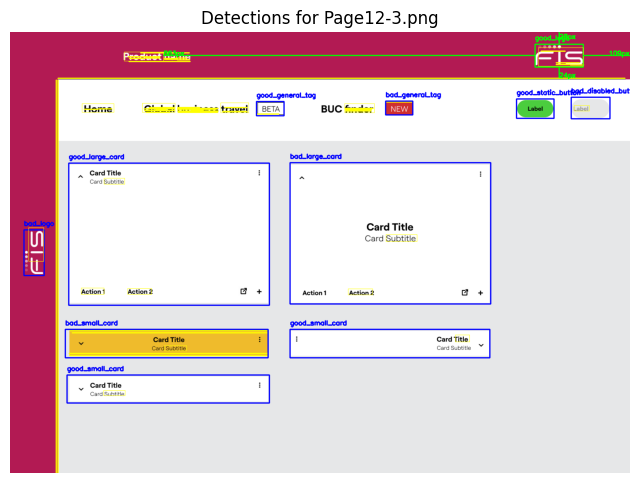


image 1/1 /content/test/Page21.png: 480x640 1 bad_logo, 3 bad_static_buttons, 1 good_disabled_button, 1 good_logo, 1 good_pie_chart, 1 good_static_button, 13.2ms
Speed: 2.7ms preprocess, 13.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Bounding Box size: 95	Minimum clearance: 27.142857142857142
Bounding Box (100, 29, 195, 75) - Distances: {'Up': 29, 'Down': np.int32(27), 'Left': 100, 'Right': 60} - INVALID


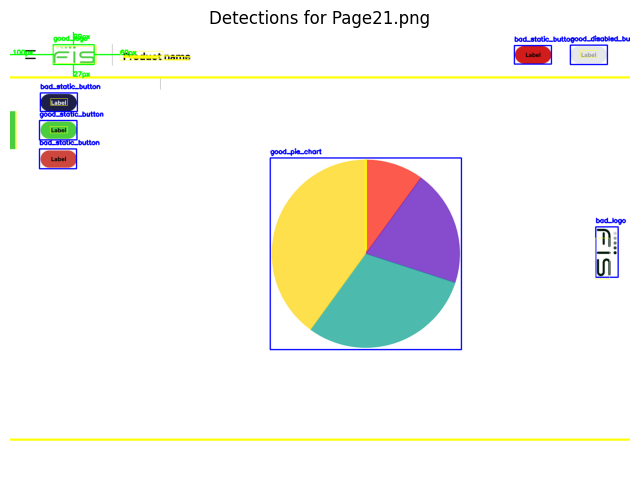


image 1/1 /content/test/Page12-1.png: 480x640 1 bad_error_tag, 2 bad_general_tags, 1 bad_logo, 1 bad_status_tag, 3 bad_success_tags, 1 good_error_tag, 2 good_logos, 1 good_pie_chart, 1 good_success_tag, 13.2ms
Speed: 2.6ms preprocess, 13.2ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Bounding Box size: 112	Minimum clearance: 32.0
Bounding Box (50, 29, 162, 82) - Distances: {'Up': 29, 'Down': np.int32(23), 'Left': 50, 'Right': 1278} - INVALID
Bounding Box size: 119	Minimum clearance: 34.0
Bounding Box (466, 141, 585, 198) - Distances: {'Up': np.int32(32), 'Down': np.int32(746), 'Left': np.int32(46), 'Right': 855} - INVALID


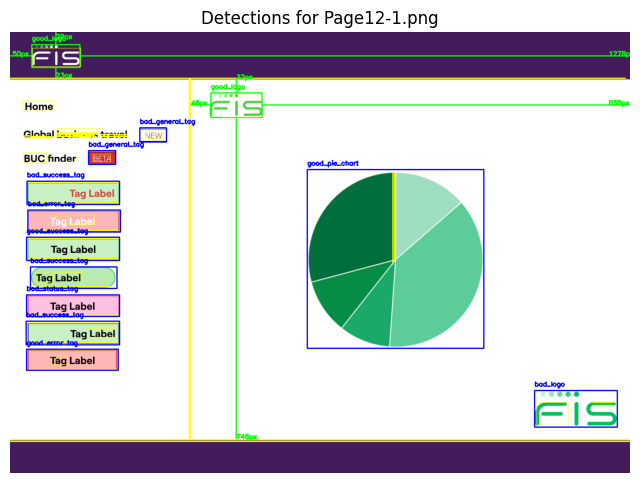


image 1/1 /content/test/Page18-1.png: 480x640 2 bad_large_cards, 1 bad_small_card, 1 bad_status_tag, 3 bad_success_tags, 1 good_disabled_button, 1 good_error_tag, 1 good_logo, 3 good_small_cards, 2 good_static_buttons, 1 good_success_tag, 13.4ms
Speed: 4.3ms preprocess, 13.4ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Bounding Box size: 111	Minimum clearance: 31.714285714285715
Bounding Box (36, 8, 147, 64) - Distances: {'Up': 8, 'Down': np.int32(37), 'Left': 36, 'Right': np.int32(1286)} - INVALID


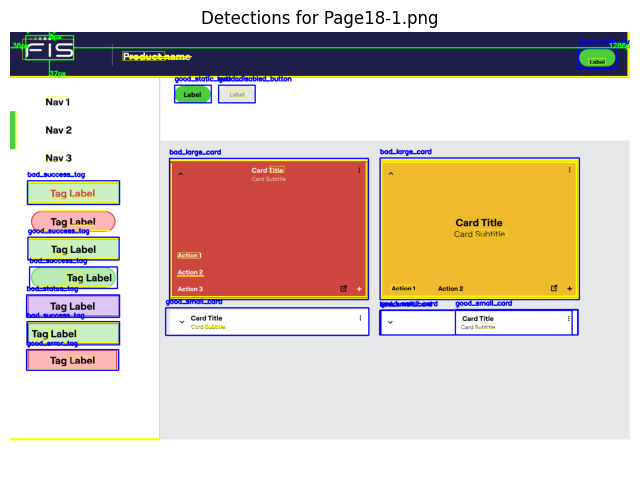


image 1/1 /content/test/Page18.png: 480x640 2 bad_large_cards, 1 bad_small_card, 1 bad_status_tag, 3 bad_success_tags, 1 good_disabled_button, 1 good_error_tag, 1 good_logo, 3 good_small_cards, 2 good_static_buttons, 1 good_success_tag, 13.3ms
Speed: 4.2ms preprocess, 13.3ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
Bounding Box size: 111	Minimum clearance: 31.714285714285715
Bounding Box (36, 8, 147, 64) - Distances: {'Up': 8, 'Down': np.int32(37), 'Left': 36, 'Right': np.int32(1286)} - INVALID


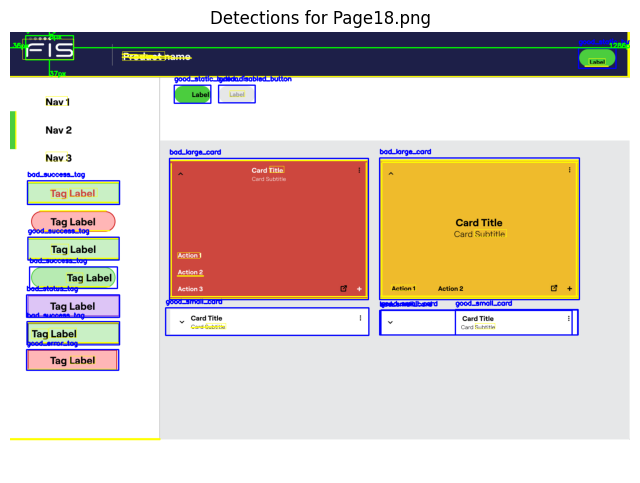


image 1/1 /content/test/Page13.png: 480x640 1 bad_general_tag, 1 bad_large_card, 2 bad_static_buttons, 1 good_disabled_button, 1 good_general_tag, 2 good_large_cards, 1 good_logo, 1 good_small_card, 13.3ms
Speed: 2.7ms preprocess, 13.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Bounding Box size: 108	Minimum clearance: 30.857142857142858
Bounding Box (44, 44, 152, 91) - Distances: {'Up': 44, 'Down': np.int32(41), 'Left': 44, 'Right': 1169} - VALID


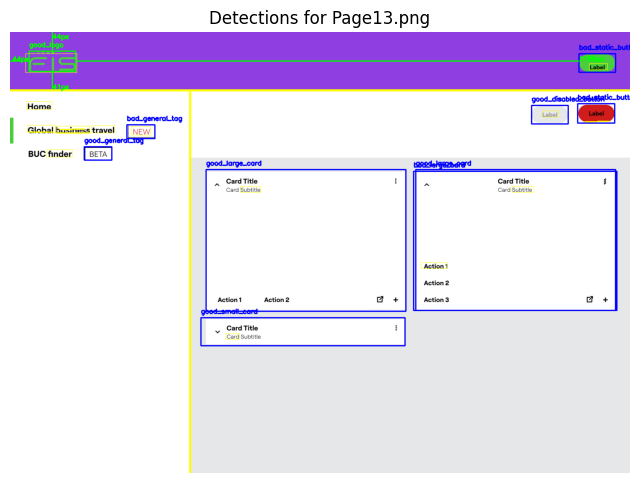


image 1/1 /content/test/Page12-2.png: 480x640 1 bad_general_tag, 1 bad_pie_chart, 1 good_disabled_button, 1 good_donut_chart, 1 good_general_tag, 1 good_logo, 2 good_static_buttons, 13.2ms
Speed: 2.6ms preprocess, 13.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Bounding Box size: 112	Minimum clearance: 32.0
Bounding Box (49, 31, 161, 83) - Distances: {'Up': 31, 'Down': np.int32(23), 'Left': 49, 'Right': 1162} - INVALID


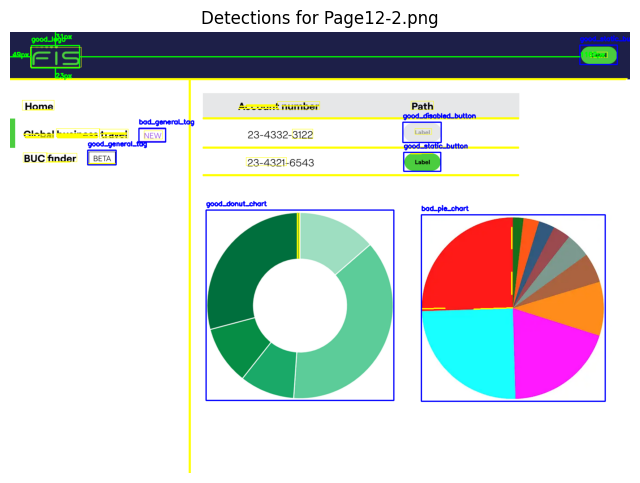


image 1/1 /content/test/Page12.png: 480x640 1 bad_disabled_button, 1 bad_large_card, 1 bad_logo, 1 bad_pie_chart, 1 bad_static_button, 2 good_general_tags, 1 good_large_card, 1 good_pie_chart, 2 good_static_buttons, 13.9ms
Speed: 4.5ms preprocess, 13.9ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)


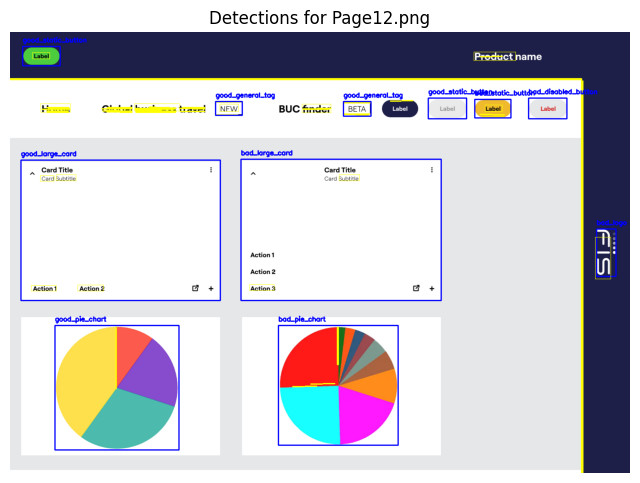


image 1/1 /content/test/Page19.png: 480x640 1 bad_general_tag, 1 bad_logo, 1 bad_static_button, 1 good_general_tag, 2 good_large_cards, 1 good_pie_chart, 2 good_static_buttons, 13.3ms
Speed: 2.7ms preprocess, 13.3ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


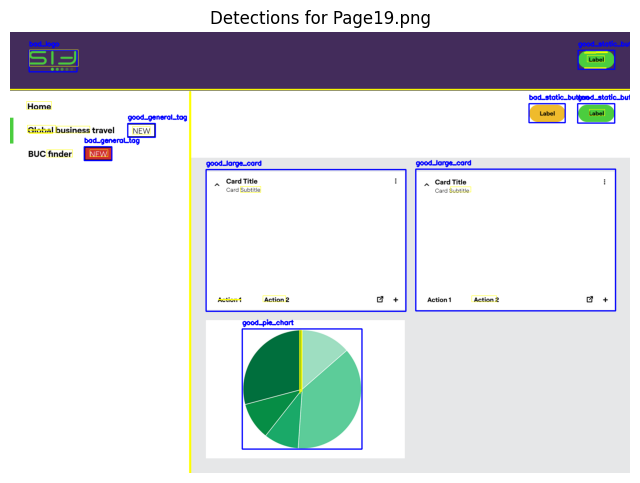

In [ ]:
import os
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Define model paths
EAST_MODEL_PATH = "frozen_east_text_detection.pb"
EAST_MODEL_URL = "https://raw.githubusercontent.com/oyyd/frozen_east_text_detection.pb/master/frozen_east_text_detection.pb"

# Download EAST model if not present
if not os.path.exists(EAST_MODEL_PATH):
    print("Downloading EAST text detection model...")
    response = requests.get(EAST_MODEL_URL, stream=True)
    if response.status_code == 200:
        with open(EAST_MODEL_PATH, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024):
                f.write(chunk)
        print("Download complete.")
    else:
        raise Exception("Failed to download the EAST model.")

# Load models
east_net = cv2.dnn.readNet(EAST_MODEL_PATH)

# Function to detect lines
def detect_and_draw_lines(image):
    """ Detects only straight horizontal and vertical lines, ensuring high contrast for blue headers.
        Returns detected line coordinates for further processing. """

    # Convert to HSV to isolate the blue header
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_blue = np.array([90, 50, 50])   # Adjust these values if needed
    upper_blue = np.array([130, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

    # Convert to grayscale, but prioritize the blue channel for better contrast
    blue_channel = image[:, :, 0]  # Extract blue channel
    enhanced_gray = cv2.addWeighted(blue_channel, 1.5, mask_blue, 0.5, 0)  # Boost blue contrast

    # Apply adaptive thresholding for improved edge detection
    binary = cv2.adaptiveThreshold(enhanced_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    # Edge detection using Canny with adaptive thresholds
    edges = cv2.Canny(binary, 30, 200)  # Adjusted thresholds

    # Use Hough Line Transform to detect only straight lines
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=80,
                            minLineLength=50, maxLineGap=5)  # Adjusted for smaller headers

    detected_lines = []  # Store detected lines

    # Draw detected lines in yellow and store them
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            # Only store and draw strictly horizontal or vertical lines
            if abs(x1 - x2) < 5 or abs(y1 - y2) < 5:
                cv2.line(image, (x1, y1), (x2, y2), (0, 255, 255), 2)  # Yellow
                detected_lines.append((x1, y1, x2, y2))

    return detected_lines  # Return list of detected lines

# Function to detect text using EAST
def detect_text_east(image):
    orig = image.copy()
    (H, W) = image.shape[:2]
    newW, newH = (W // 32) * 32, (H // 32) * 32
    rW, rH = W / float(newW), H / float(newH)

    image = cv2.resize(image, (newW, newH))
    blob = cv2.dnn.blobFromImage(image, 1.0, (newW, newH), (123.68, 116.78, 103.94), swapRB=True, crop=False)
    east_net.setInput(blob)

    scores, geometry = east_net.forward(["feature_fusion/Conv_7/Sigmoid", "feature_fusion/concat_3"])
    rects, confidences = [], []
    for y in range(scores.shape[2]):
        for x in range(scores.shape[3]):
            if scores[0, 0, y, x] < 0.5:
                continue
            offsetX, offsetY = x * 4.0, y * 4.0
            angle = geometry[0, 4, y, x]
            cos, sin = np.cos(angle), np.sin(angle)
            h, w = geometry[0, 0, y, x] + geometry[0, 2, y, x], geometry[0, 1, y, x] + geometry[0, 3, y, x]
            endX, endY = int(offsetX + (cos * geometry[0, 1, y, x]) + (sin * geometry[0, 2, y, x])), int(offsetY - (sin * geometry[0, 1, y, x]) + (cos * geometry[0, 2, y, x]))
            startX, startY = int(endX - w), int(endY - h)
            rects.append((startX, startY, endX, endY))
            confidences.append(float(scores[0, 0, y, x]))

    boxes = cv2.dnn.NMSBoxes(rects, confidences, score_threshold=0.5, nms_threshold=0.4)
    return [(rects[i]) for i in boxes.flatten()] if len(boxes) > 0 else []

def draw_perpendicular_lines(image, ref_box, detections):
    x1, y1, x2, y2 = ref_box
    center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2

    distances = {}  # Store distances for all directions

    # Define four movement directions: Up, Down, Left, Right
    directions = {
        "Up": (center_x, y1, center_x, 0),     # From top boundary to box top
        "Down": (center_x, y2, center_x, image.shape[0]),  # From box bottom to image bottom
        "Left": (x1, center_y, 0, center_y),   # From left boundary to box left
        "Right": (x2, center_y, image.shape[1], center_y)  # From box right to image right
    }

    # Convert detected lines into obstacles (small-width bounding boxes)
    line_obstacles = []
    for (lx1, ly1, lx2, ly2) in detections:
        if abs(lx1 - lx2) < 5:  # Vertical line
            line_obstacles.append((lx1 - 2, min(ly1, ly2), lx1 + 2, max(ly1, ly2)))  # Small-width box
        elif abs(ly1 - ly2) < 5:  # Horizontal line
            line_obstacles.append((min(lx1, lx2), ly1 - 2, max(lx1, lx2), ly1 + 2))  # Small-height box

    # Combine text boxes, YOLO boxes, and detected lines
    all_obstacles = detections + line_obstacles

    for direction, (x_start, y_start, x_end, y_end) in directions.items():
        # Initialize final end coordinates
        final_x, final_y = x_end, y_end

        # Check for obstacles in the path
        for (bx1, by1, bx2, by2) in all_obstacles:
            if "Up" in direction and bx1 <= center_x <= bx2 and by2 < y1:
                final_y = max(final_y, by2)  # Stop at the closest component **above**
            elif "Down" in direction and bx1 <= center_x <= bx2 and by1 > y2:
                final_y = min(final_y, by1)  # Stop at the closest component **below**
            elif "Left" in direction and by1 <= center_y <= by2 and bx2 < x1:
                final_x = max(final_x, bx2)  # Stop at the closest component **to the right** (Fix)
            elif "Right" in direction and by1 <= center_y <= by2 and bx1 > x2:
                final_x = min(final_x, bx1)  # Stop at the closest component **to the left**

        # Draw the final adjusted line
        cv2.line(image, (x_start, y_start), (final_x, final_y), (0, 255, 0), 2)

        # Calculate and store distance
        distance = abs(final_y - y_start) if "Up" in direction or "Down" in direction else abs(final_x - x_start)
        distances[direction] = distance

        # Ensure text does not go out of bounds
        text_x, text_y = max(5, min(final_x, image.shape[1] - 50)), max(15, min(final_y, image.shape[0] - 5))
        cv2.putText(image, f"{distance}px", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    bbox_size = max(x2 - x1, y2 - y1)  # Take the larger dimension as size
    min_clearance = bbox_size / 3.5  # Bounding box length of clear space required

    print(f"Bounding Box size: {bbox_size}\tMinimum clearance: {min_clearance}")

    # Ensure bounding box size is more than 18 pixels
    if bbox_size <= 18:
        print(f"Bounding Box ({x1}, {y1}, {x2}, {y2}) is too small (Size: {bbox_size}px) - INVALID")
        return False

    # Check if all distances are greater than min_clearance
    if all(d > min_clearance for d in distances.values()):
        print(f"Bounding Box ({x1}, {y1}, {x2}, {y2}) - Distances: {distances} - VALID")
        return True
    else:
        print(f"Bounding Box ({x1}, {y1}, {x2}, {y2}) - Distances: {distances} - INVALID")
        return False

# Process images
IMAGE_DIR = "./test/"
image_files = [os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Process each image
for image_file in image_files:
    img = cv2.imread(image_file)
    results = model(image_file)
    text_boxes = detect_text_east(img)

    yolo_boxes = []
    good_logo_boxes = []  # Store multiple detections of "good_logo"

    # Detect and store straight lines
    detected_lines = detect_and_draw_lines(img)  # Now stores the lines

    for result in results[0].boxes:
        x1, y1, x2, y2 = map(int, result.xyxy[0].tolist())
        label = model.names[int(result.cls[0].item())]
        color = (255, 0, 0) if label != "good_logo" else (0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        if label == "good_logo":
            good_logo_boxes.append((x1, y1, x2, y2))  # Append all detections

        yolo_boxes.append((x1, y1, x2, y2))

    for (tx1, ty1, tx2, ty2) in text_boxes:
        cv2.rectangle(img, (tx1, ty1), (tx2, ty2), (0, 255, 255), 1)  # Yellow for text

    # Draw perpendicular lines for ALL detected "good_logo" instances
    for good_logo_box in good_logo_boxes:
        draw_perpendicular_lines(img, good_logo_box, yolo_boxes + text_boxes + detected_lines)
        # Now passing detected lines too!

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Detections for {os.path.basename(image_file)}")
    plt.show()